# Context Assembler Compare Rankings — Accuracy & FNR Analysis

Compares context assembler ranking strategies on the same benchmark
using model `qwen3-8b-thinking-sc5` (5 self-consistency passes per sample).

Each approach was run **once**, but every sample is predicted with **5 self-consistency
passes**. Those passes are used in two ways:

1. **Independent-pass mode** — each self-consistency pass is scored *separately*, as if
   the model had been run 5 times on the sample. Confusion-matrix counts are summed over
   (samples × passes). This is the new default for the aggregate/baseline metrics below.
2. **Self-confidence mode** — for each sample, the fraction of passes that agree with the
   majority label defines a per-sample *confidence score*. At each confidence threshold
   only the 'certain enough' samples are scored; the rest are abstained.

Two ranking families were hyper-parameter tuned, so they exist in three parameter
settings — **manual** (`*_default`), **best** (`*`) and **last** (`*_last`). A dedicated
section compares those parameter combinations per ranking method.

Key questions:
- Which ranking strategy produces the best accuracy / lowest FNR?
- For a tuned ranking method, how do the manual / best / last parameters compare?
- Does applying a self-confidence threshold improve accuracy or FNR for any approach?

In [77]:
import json
import math
from pathlib import Path
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
matplotlib.rcParams['figure.dpi'] = 120

In [78]:
# Configuration

PROJECT_ROOT = Path('__file__').resolve().parent.parent
RESULTS_DIR  = (
    PROJECT_ROOT / 'results'
    / 'context_assembler_compare_rankings_experiments'
    / 'vllm_compare_rankings'
)
MODEL_NAME  = 'qwen3-8b-thinking-sc5'
PROMPT_TYPE = 'python_exploit_chain'

# Short display name for each approach directory
APPROACH_DISPLAY = {
    'context_assembler_compare_current':                       'Лин. коэф. (настройка)',
    'context_assembler_compare_current_default':               'Лин. коэф. (вручную)',
    'context_assembler_compare_current_last':                  'Лин. коэф. (последнее)',
    'context_assembler_compare_multiplicative_amplification':          'Мультипл. коэф. (настройка)',
    'context_assembler_compare_multiplicative_amplification_default':  'Мультипл. коэф. (вручную)',
    'context_assembler_compare_multiplicative_amplification_last':  'Мультипл. коэф. (последнее)',
    'context_assembler_compare_depth_repeats_context':         'Повторы и глубина',
    'context_assembler_compare_cpg_structural':                'По типам рёбер',
    'context_assembler_compare_cpg_structural_last':                'По типам рёбер (последнее)',
    'context_assembler_compare_dummy':                'Последовательно',
    'context_assembler_compare_random_picking':                'Случайный выбор',
    'context_assembler_compare_evidence_budgeted':                'Бюджет доказательств',
    'context_assembler_compare_evidence_budgeted_last':                'Бюджет доказательств (последнее)'
}

# Self-confidence thresholds (fraction of self-consistency passes agreeing with majority)
CONF_THRESHOLDS = [0.6, 0.8, 1.0]   # e.g. 3/5, 4/5, 5/5 for 5-pass experiments

APPROACH_COLORS = [
    '#4e79a7', '#f28e2b', '#e15759', '#59a14f',
    '#b07aa1', '#ff9da7', '#9c755f', '#bab0ac',
    '#000000', '#d37295', '#f1ce63', '#b2e061',
    '#ff9da7', '#9c755f', '#bab0ac'
]

In [79]:
# Helpers

def recompute_metrics(tp, tn, fp, fn):
    """All classification metrics from raw confusion matrix counts."""
    n    = tp + tn + fp + fn
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    denom = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc   = (tp * tn - fp * fn) / denom if denom else 0.0
    return dict(
        accuracy=(tp + tn) / n if n else 0.0,
        precision=prec, recall=rec, f1=f1,
        specificity=spec, FNR=1 - rec, FPR=1 - spec, MCC=mcc,
        TP=tp, TN=tn, FP=fp, FN=fn,
    )


def load_reports(approach_dir):
    """Return list of parsed benchmark_report JSON dicts (all runs)."""
    run_dir = approach_dir / MODEL_NAME / PROMPT_TYPE
    reports = []
    for path in sorted(run_dir.glob('benchmark_report_*.json')):
        with open(path) as f:
            reports.append(json.load(f))
    return reports


def aggregate_metrics(reports):
    """Sum the (majority-vote) confusion matrices across all runs and recompute metrics."""
    tp = tn = fp = fn = 0
    for r in reports:
        cm = r['metrics']['details']['confusion_matrix']
        tp += cm['true_positives']
        tn += cm['true_negatives']
        fp += cm['false_positives']
        fn += cm['false_negatives']
    return {**recompute_metrics(tp, tn, fp, fn), 'n_runs': len(reports)}


def independent_pass_metrics(reports):
    """Score every self-consistency pass as an independent prediction.

    Instead of collapsing a sample's N self-consistency passes into one
    majority-vote label, each pass is scored on its own — as if the model had
    been run N separate times on that sample. Confusion-matrix counts are
    therefore summed over (samples x passes), read straight from ``vote_counts``.
    """
    tp = tn = fp = fn = 0
    for r in reports:
        for pred in r['predictions']:
            if not pred.get('is_success', True):
                continue
            true = int(pred['true_label'])
            for label_str, count in pred['inference_data']['vote_counts'].items():
                lbl = int(label_str)
                if   true == 1 and lbl == 1:
                    tp += count
                elif true == 1 and lbl == 0:
                    fn += count
                elif true == 0 and lbl == 1:
                    fp += count
                else:
                    tn += count
    n_passes = tp + tn + fp + fn
    return {**recompute_metrics(tp, tn, fp, fn),
            'n_runs': len(reports), 'n_passes': n_passes}


def build_per_sample_table(reports):
    """
    Build a per-sample table by aggregating vote_counts from inference_data
    across all runs. Each report's predictions carry vote_counts from
    self-consistency draws (self_consistency_samples per run).
    Returns a DataFrame indexed by sample_id with columns:
      true_label, majority_pred, confidence
    where confidence = max_votes / total_votes (across all runs x draws).
    """
    sample_rows = {}
    for report in reports:
        for pred in report['predictions']:
            if not pred.get('is_success', True):
                continue
            sid = pred['sample_id']
            if sid not in sample_rows:
                sample_rows[sid] = {
                    'true_label':  int(pred['true_label']),
                    'vote_counts': Counter(),
                }
            for label_str, count in pred['inference_data']['vote_counts'].items():
                sample_rows[sid]['vote_counts'][int(label_str)] += count

    rows = {}
    for sid, data in sample_rows.items():
        counts      = data['vote_counts']
        total_votes = sum(counts.values())
        maj_label   = max(counts, key=counts.get)
        maj_votes   = counts[maj_label]
        rows[sid] = {
            'true_label':    data['true_label'],
            'majority_pred': maj_label,
            'confidence':    maj_votes / total_votes if total_votes else 0.0,
        }

    df = pd.DataFrame.from_dict(rows, orient='index')
    df.index.name = 'sample_id'
    return df


def metrics_at_threshold(sample_df, threshold):
    """
    Compute metrics only on samples whose self-confidence >= threshold.
    Returns dict with metrics + coverage (fraction of samples retained).
    """
    sub = sample_df[sample_df['confidence'] >= threshold - 1e-9]
    coverage = len(sub) / len(sample_df)
    tp = int(((sub['majority_pred'] == 1) & (sub['true_label'] == 1)).sum())
    tn = int(((sub['majority_pred'] == 0) & (sub['true_label'] == 0)).sum())
    fp = int(((sub['majority_pred'] == 1) & (sub['true_label'] == 0)).sum())
    fn = int(((sub['majority_pred'] == 0) & (sub['true_label'] == 1)).sum())
    return {**recompute_metrics(tp, tn, fp, fn), 'coverage': coverage, 'n_samples': len(sub)}

In [80]:
# Load data

approach_dirs = [
    d for d in sorted(RESULTS_DIR.iterdir())
    if d.is_dir() and d.name in APPROACH_DISPLAY
]

# Dict: approach_dir_name -> {reports, sample_df}
data = {}
for d in approach_dirs:
    reports = load_reports(d)
    if not reports:
        continue
    sample_df = build_per_sample_table(reports)
    data[d.name] = {'reports': reports, 'sample_df': sample_df}

for name, v in data.items():
    print(
        f"{APPROACH_DISPLAY[name]:>20}  "
        f"{len(v['reports'])} runs  "
        f"{len(v['sample_df'])} samples"
    )

      По типам рёбер  1 runs  400 samples
По типам рёбер (последнее)  1 runs  400 samples
Лин. коэф. (настройка)  1 runs  400 samples
Лин. коэф. (вручную)  1 runs  400 samples
Лин. коэф. (последнее)  1 runs  400 samples
   Повторы и глубина  1 runs  400 samples
     Последовательно  1 runs  400 samples
Бюджет доказательств  1 runs  400 samples
Бюджет доказательств (последнее)  1 runs  400 samples
Мультипл. коэф. (настройка)  1 runs  400 samples
Мультипл. коэф. (вручную)  1 runs  400 samples
Мультипл. коэф. (последнее)  1 runs  400 samples
     Случайный выбор  1 runs  400 samples


In [81]:
# Build summary DataFrames

# 1. Independent-pass metrics (each self-consistency pass scored separately)
agg_rows = []
for name, v in data.items():
    m = independent_pass_metrics(v['reports'])
    agg_rows.append({'approach': APPROACH_DISPLAY[name], **m})
agg_df = pd.DataFrame(agg_rows).sort_values('accuracy', ascending=False).reset_index(drop=True)

# 2. Self-confidence filtered at each threshold
all_thresholds = [0.0] + CONF_THRESHOLDS   # 0.0 = all samples = majority-vote baseline

full_conf_rows = []
for name, v in data.items():
    for thr in all_thresholds:
        m = metrics_at_threshold(v['sample_df'], thr)
        full_conf_rows.append({'approach': APPROACH_DISPLAY[name], 'threshold': thr, **m})
full_conf_df = pd.DataFrame(full_conf_rows)

approaches_by_agg_acc = agg_df['approach'].tolist()

print('Independent-pass metrics (each self-consistency pass scored separately, no confidence filter):')
display(
    agg_df[['approach', 'n_runs', 'n_passes', 'TP', 'TN', 'FP', 'FN',
            'accuracy', 'FNR', 'FPR', 'f1', 'MCC']]
    .round(4)
    .style
    .background_gradient(subset=['accuracy', 'f1', 'MCC'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['FNR', 'FPR'], cmap='RdYlGn_r', axis=0)
    .format('{:.4f}', subset=['accuracy', 'FNR', 'FPR', 'f1', 'MCC'])
)

Independent-pass metrics (each self-consistency pass scored separately, no confidence filter):


,approach,n_runs,n_passes,TP,TN,FP,FN,accuracy,FNR,FPR,f1,MCC
0,Мультипл. коэф. (настройка),1,3535,916,1127,638,854,0.5779,0.4825,0.3615,0.5511,0.1572
1,Лин. коэф. (последнее),1,3535,903,1130,635,867,0.5751,0.4898,0.3598,0.5459,0.1517
2,По типам рёбер,1,3530,877,1153,612,888,0.5751,0.5031,0.3467,0.5390,0.1520
3,Лин. коэф. (вручную),1,3535,895,1135,630,875,0.5743,0.4944,0.3569,0.5432,0.1501
4,Лин. коэф. (настройка),1,3535,885,1139,626,885,0.5726,0.5000,0.3547,0.5395,0.1469
5,Бюджет доказательств (последнее),1,3530,876,1145,620,889,0.5725,0.5037,0.3513,0.5373,0.1468
6,Бюджет доказательств,1,3530,850,1170,595,915,0.5722,0.5184,0.3371,0.5296,0.1469
7,Повторы и глубина,1,3535,860,1158,607,910,0.5709,0.5141,0.3439,0.5314,0.1441
8,Последовательно,1,3535,859,1155,615,906,0.5697,0.5133,0.3475,0.5304,0.1412
9,По типам рёбер (последнее),1,3530,836,1171,594,929,0.5686,0.5263,0.3365,0.5233,0.1396


## Baseline Comparison (Independent Self-Consistency Passes, No Confidence Filter)

Every self-consistency pass is counted as its own prediction (≈ 5 predictions per sample).

/tmp/ipykernel_539628/1960997643.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=30, ha='right')
/tmp/ipykernel_539628/1960997643.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=30, ha='right')


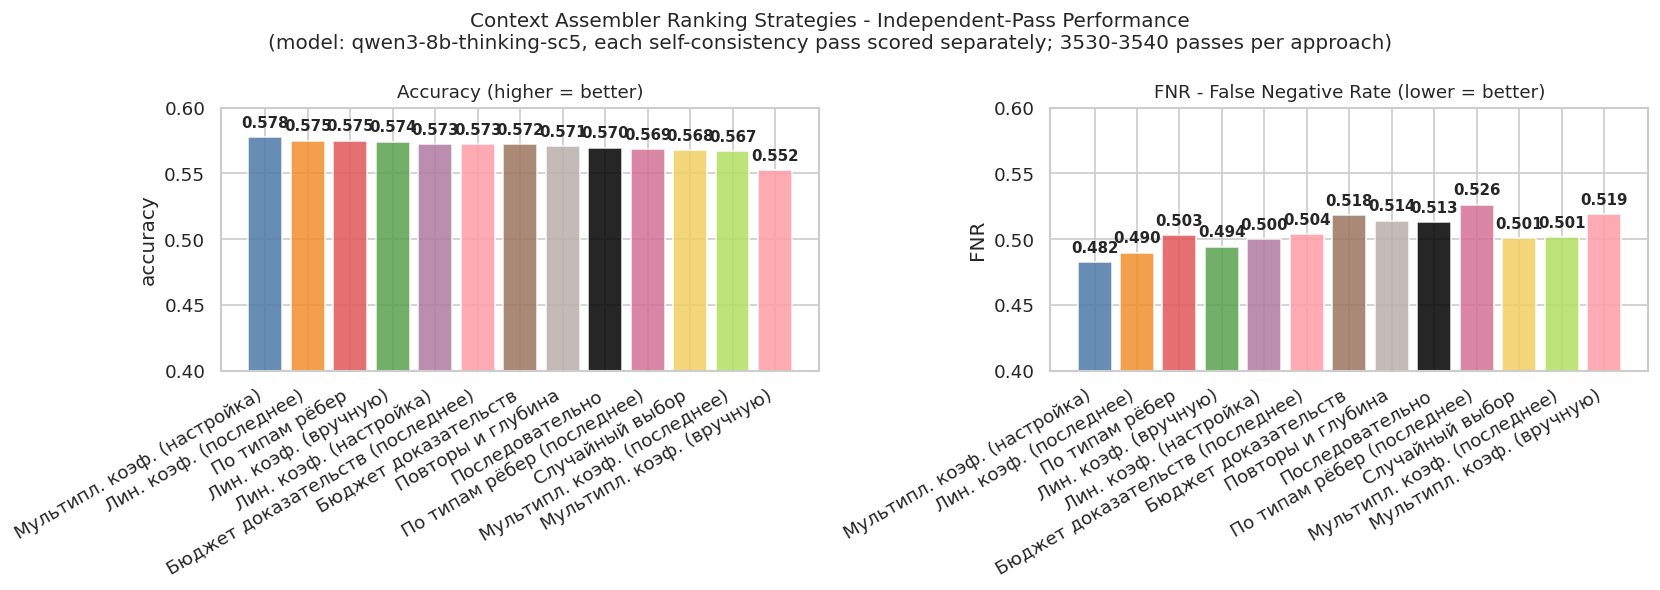

In [82]:
# Bar chart: Accuracy & FNR by approach

colors = APPROACH_COLORS[:len(agg_df)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, title) in zip(axes, [
    ('accuracy', 'Accuracy (higher = better)'),
    ('FNR',      'FNR - False Negative Rate (lower = better)'),
]):
    vals  = agg_df[col].values
    names = agg_df['approach'].tolist()
    bars  = ax.bar(names, vals, color=colors, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylim(0.4, 0.6)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(col)
    ax.set_xticklabels(names, rotation=30, ha='right')

n_pass_range = f"{agg_df['n_passes'].min()}-{agg_df['n_passes'].max()}"
fig.suptitle(
    f'Context Assembler Ranking Strategies - Independent-Pass Performance\n'
    f'(model: {MODEL_NAME}, each self-consistency pass scored separately; '
    f'{n_pass_range} passes per approach)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

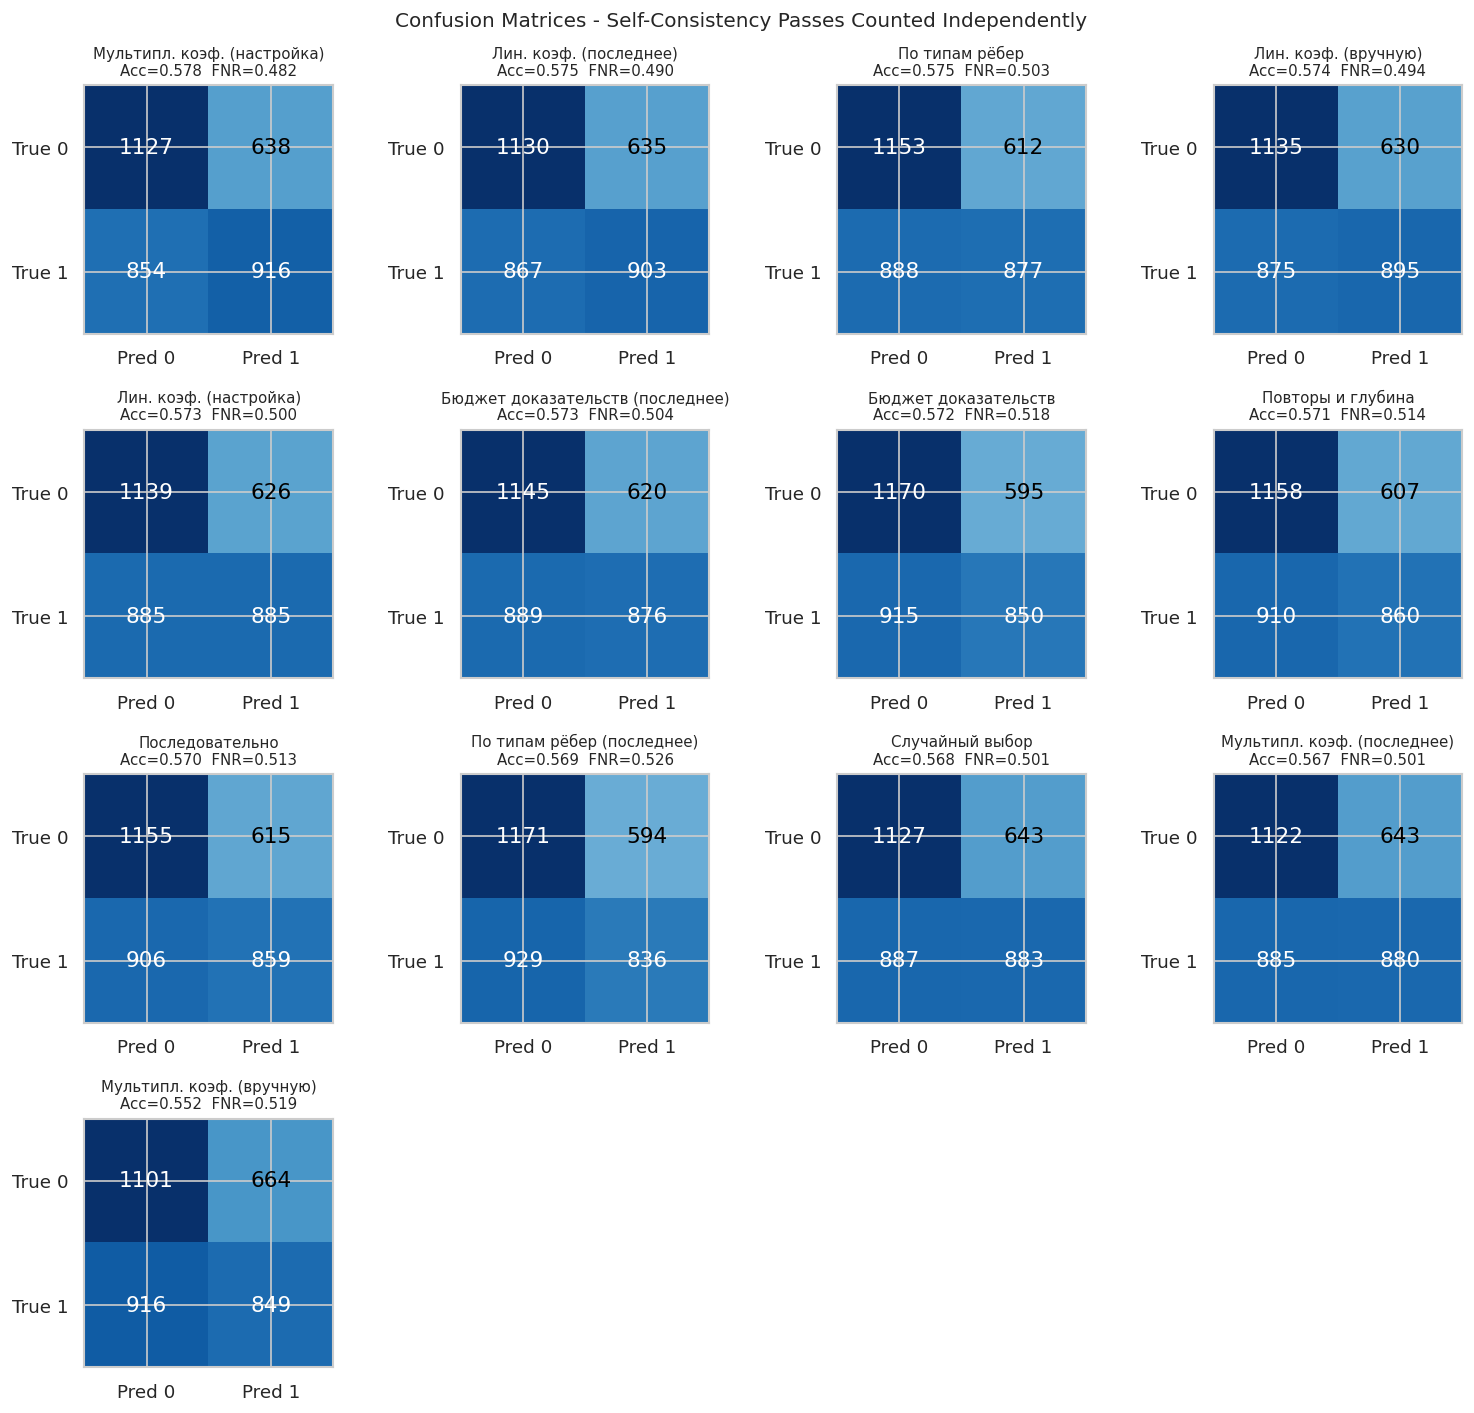

In [83]:
# Confusion matrix heatmap grid

n_ap  = len(agg_df)
ncols = min(4, n_ap)
nrows = math.ceil(n_ap / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.0))
axes = np.array(axes).flatten()

for ax, (_, row) in zip(axes, agg_df.iterrows()):
    cm_arr = np.array([[row['TN'], row['FP']],
                       [row['FN'], row['TP']]])
    ax.imshow(cm_arr, cmap='Blues', vmin=0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(int(cm_arr[i, j])), ha='center', va='center',
                    fontsize=13,
                    color='black' if cm_arr[i, j] < cm_arr.max() * 0.7 else 'white')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['True 0', 'True 1'])
    ax.set_title(
        f"{row['approach']}\nAcc={row['accuracy']:.3f}  FNR={row['FNR']:.3f}",
        fontsize=9,
    )

for ax in axes[n_ap:]:
    ax.set_visible(False)

fig.suptitle('Confusion Matrices - Self-Consistency Passes Counted Independently', fontsize=12)
fig.tight_layout()
plt.show()

## Параметры ранжирования: вручную / лучшее / последнее

Some ranking families were hyper-parameter tuned and therefore exist in several
parameter settings on the same benchmark:

| Семейство | Вручную (`*_default`) | Лучшее (`*`) | Последнее (`*_last`) |
|---|:---:|:---:|:---:|
| Лин. коэф. | ✓ | ✓ | ✓ |
| Мультипл. коэф. | ✓ | ✓ | ✓ |
| По типам рёбер | — | ✓ | ✓ |
| Бюджет доказательств | — | ✓ | ✓ |

- **Вручную** — hand-picked default parameters.
- **Лучшее** — best configuration found during tuning.
- **Последнее** — the final / last tuned parameter values.

All metrics below count every self-consistency pass independently (≈ 5 predictions per sample),
matching the baseline section above.

In [84]:
# Hyperparameter-variant comparison: manual vs best vs last
# Each family maps a parameter setting -> results directory. Missing settings
# (e.g. no manual variant) are simply skipped.

PARAM_FAMILY_DIRS = {
    'Лин. коэф.': {
        'Вручную':   'context_assembler_compare_current_default',
        'Лучшее':    'context_assembler_compare_current',
        'Последнее': 'context_assembler_compare_current_last',
    },
    'Мультипл. коэф.': {
        'Вручную':   'context_assembler_compare_multiplicative_amplification_default',
        'Лучшее':    'context_assembler_compare_multiplicative_amplification',
        'Последнее': 'context_assembler_compare_multiplicative_amplification_last',
    },
    'По типам рёбер': {
        'Лучшее':    'context_assembler_compare_cpg_structural',
        'Последнее': 'context_assembler_compare_cpg_structural_last',
    },
    'Бюджет доказательств': {
        'Лучшее':    'context_assembler_compare_evidence_budgeted',
        'Последнее': 'context_assembler_compare_evidence_budgeted_last',
    },
}
PARAM_ORDER  = ['Вручную', 'Лучшее', 'Последнее']
PARAM_COLORS = {'Вручную': '#bab0ac', 'Лучшее': '#4e79a7', 'Последнее': '#f28e2b'}

param_rows = []
for family, variants in PARAM_FAMILY_DIRS.items():
    for param, dirname in variants.items():
        reports = load_reports(RESULTS_DIR / dirname)
        if not reports:
            print(f'  ! no reports found for {dirname} - skipping')
            continue
        m = independent_pass_metrics(reports)
        param_rows.append({'family': family, 'param': param, **m})

param_df = pd.DataFrame(param_rows)
param_df['param'] = pd.Categorical(param_df['param'], categories=PARAM_ORDER, ordered=True)
param_df = param_df.sort_values(['family', 'param']).reset_index(drop=True)

display(
    param_df[['family', 'param', 'n_passes', 'TP', 'TN', 'FP', 'FN',
              'accuracy', 'FNR', 'FPR', 'f1', 'MCC']]
    .round(4)
    .style
    .background_gradient(subset=['accuracy', 'f1', 'MCC'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['FNR', 'FPR'], cmap='RdYlGn_r', axis=0)
    .format('{:.4f}', subset=['accuracy', 'FNR', 'FPR', 'f1', 'MCC'])
    .set_caption('Метрики по параметрам ранжирования (независимые проходы self-consistency)')
)

,family,param,n_passes,TP,TN,FP,FN,accuracy,FNR,FPR,f1,MCC
0,Бюджет доказательств,Лучшее,3530,850,1170,595,915,0.5722,0.5184,0.3371,0.5296,0.1469
1,Бюджет доказательств,Последнее,3530,876,1145,620,889,0.5725,0.5037,0.3513,0.5373,0.1468
2,Лин. коэф.,Вручную,3535,895,1135,630,875,0.5743,0.4944,0.3569,0.5432,0.1501
3,Лин. коэф.,Лучшее,3535,885,1139,626,885,0.5726,0.5000,0.3547,0.5395,0.1469
4,Лин. коэф.,Последнее,3535,903,1130,635,867,0.5751,0.4898,0.3598,0.5459,0.1517
5,Мультипл. коэф.,Вручную,3530,849,1101,664,916,0.5524,0.5190,0.3762,0.5180,0.1059
6,Мультипл. коэф.,Лучшее,3535,916,1127,638,854,0.5779,0.4825,0.3615,0.5511,0.1572
7,Мультипл. коэф.,Последнее,3530,880,1122,643,885,0.5671,0.5014,0.3643,0.5353,0.1356
8,По типам рёбер,Лучшее,3530,877,1153,612,888,0.5751,0.5031,0.3467,0.5390,0.1520
9,По типам рёбер,Последнее,3530,836,1171,594,929,0.5686,0.5263,0.3365,0.5233,0.1396


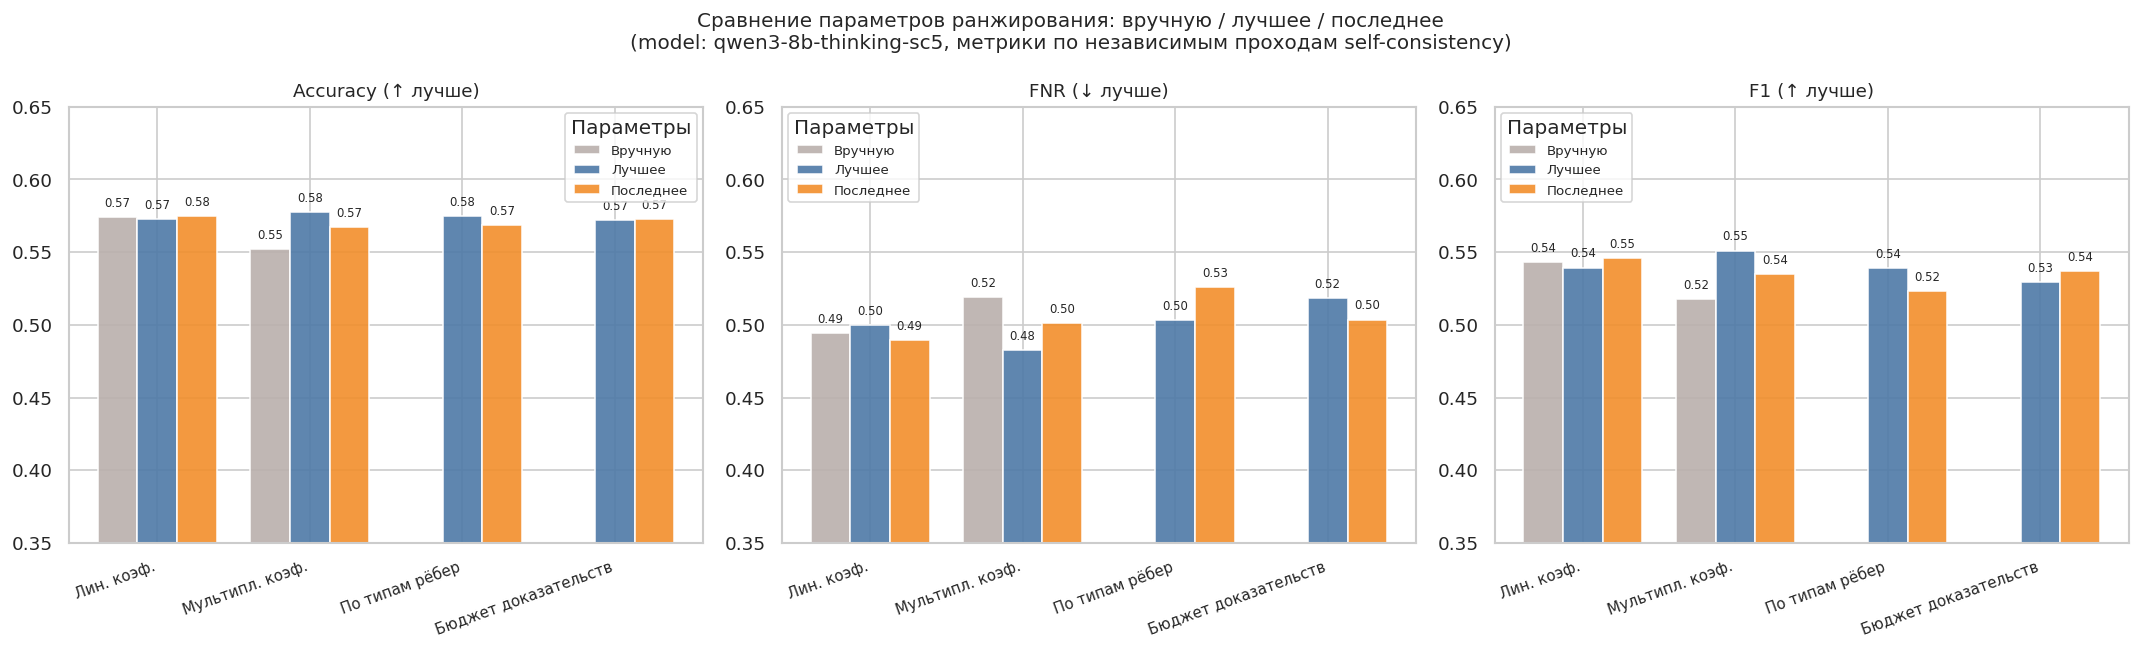

In [85]:
# Grouped bar chart: metric per ranking family, split by parameter setting

metrics_to_plot = [
    ('accuracy', 'Accuracy (↑ лучше)'),
    ('FNR',      'FNR (↓ лучше)'),
    ('f1',       'F1 (↑ лучше)'),
]
families = list(PARAM_FAMILY_DIRS)
x     = np.arange(len(families))
width = 0.26

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (col, title) in zip(axes, metrics_to_plot):
    for i, param in enumerate(PARAM_ORDER):
        vals = []
        for fam in families:
            row = param_df[(param_df['family'] == fam) & (param_df['param'] == param)]
            vals.append(row[col].iloc[0] if len(row) else np.nan)
        offs = (i - (len(PARAM_ORDER) - 1) / 2) * width
        bars = ax.bar(x + offs, vals, width, label=param,
                      color=PARAM_COLORS[param], edgecolor='white', alpha=0.9)
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(b.get_x() + b.get_width() / 2, v + 0.005,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(families, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0.35, 0.65)
    ax.set_title(title, fontsize=11)
    ax.legend(title='Параметры', fontsize=8)

fig.suptitle(
    'Сравнение параметров ранжирования: вручную / лучшее / последнее\n'
    f'(model: {MODEL_NAME}, метрики по независимым проходам self-consistency)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

## Self-Confidence Distribution

For each sample, *confidence* = fraction of runs that agree with the majority-vote predicted label.
A confidence of 1.0 means **all** runs predicted the same label; 0.6 means only 3 out of 5 agreed.
Samples with low confidence are ambiguous - the model keeps 'changing its mind' across runs.

Confidence levels found across all approaches: [np.float64(0.5), np.float64(0.5333333333333333), np.float64(0.6), np.float64(0.6666666666666666), np.float64(0.7), np.float64(0.7333333333333333), np.float64(0.8), np.float64(0.8666666666666667), np.float64(0.9), np.float64(0.9333333333333333), np.float64(1.0)]


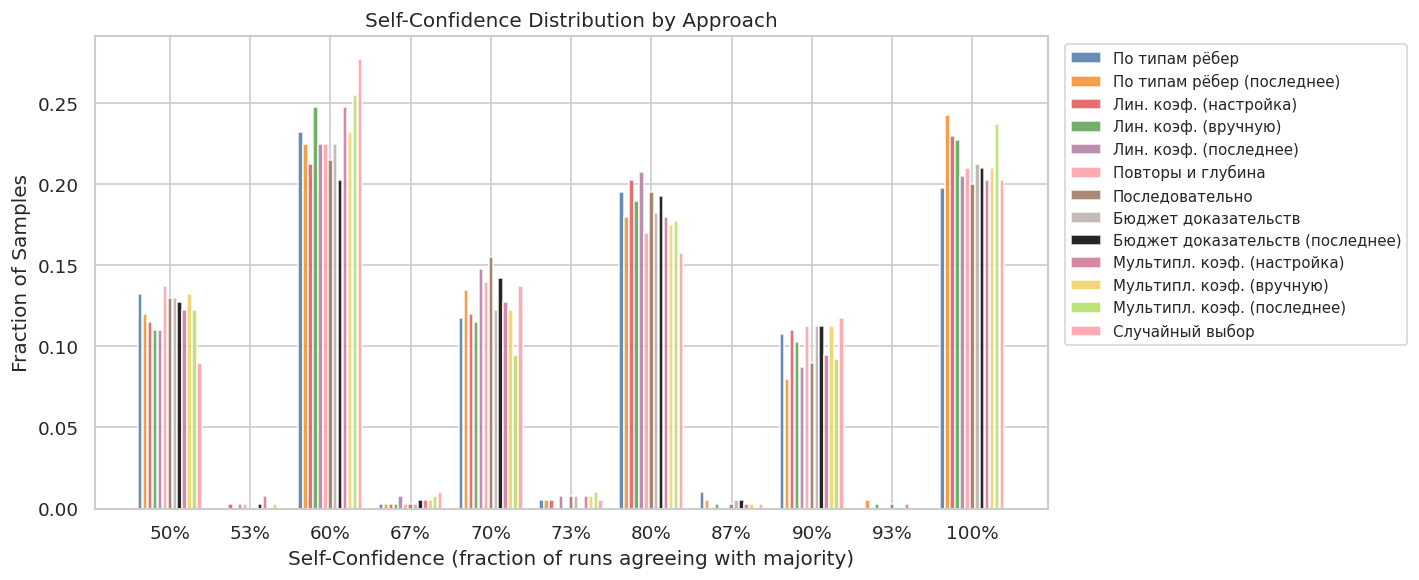

,>=60%,>=80%,>=100%
approach,,,
По типам рёбер,86.8%,51.0%,19.8%
По типам рёбер (последнее),88.0%,51.2%,24.2%
Лин. коэф. (настройка),88.2%,54.2%,23.0%
Лин. коэф. (вручную),89.0%,52.5%,22.8%
Лин. коэф. (последнее),88.8%,50.0%,20.5%
Повторы и глубина,86.0%,49.2%,21.0%
Последовательно,87.0%,49.0%,20.0%
Бюджет доказательств,87.0%,51.2%,21.2%
Бюджет доказательств (последнее),87.0%,52.0%,21.0%


In [86]:
# Confidence distribution per approach

conf_levels = sorted(
    set(v for vv in data.values() for v in vv['sample_df']['confidence'].unique())
)

print(f'Confidence levels found across all approaches: {conf_levels}')

x     = np.arange(len(conf_levels))
bar_w = 0.8 / len(data)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, v) in enumerate(data.items()):
    counts = (
        v['sample_df']['confidence']
        .value_counts(normalize=True)
        .reindex(conf_levels, fill_value=0)
    )
    ax.bar(x + i * bar_w, counts.values, bar_w * 0.9,
           label=APPROACH_DISPLAY[name], color=APPROACH_COLORS[i], alpha=0.85)

ax.set_xticks(x + bar_w * (len(data) - 1) / 2)
ax.set_xticklabels([f'{c:.0%}' for c in conf_levels])
ax.set_xlabel('Self-Confidence (fraction of runs agreeing with majority)')
ax.set_ylabel('Fraction of Samples')
ax.set_title('Self-Confidence Distribution by Approach')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

# Coverage at each threshold
cov_rows = []
for name, v in data.items():
    sdf = v['sample_df']
    row = {'approach': APPROACH_DISPLAY[name]}
    for thr in CONF_THRESHOLDS:
        row[f'>={thr:.0%}'] = (sdf['confidence'] >= thr - 1e-9).sum() / len(sdf)
    cov_rows.append(row)

display(
    pd.DataFrame(cov_rows).set_index('approach')
    .round(3)
    .style
    .background_gradient(cmap='Blues', axis=None)
    .format('{:.1%}')
    .set_caption('Coverage (fraction of samples retained) at Each Self-Confidence Threshold')
)

## Self-Confidence Filtered Metrics

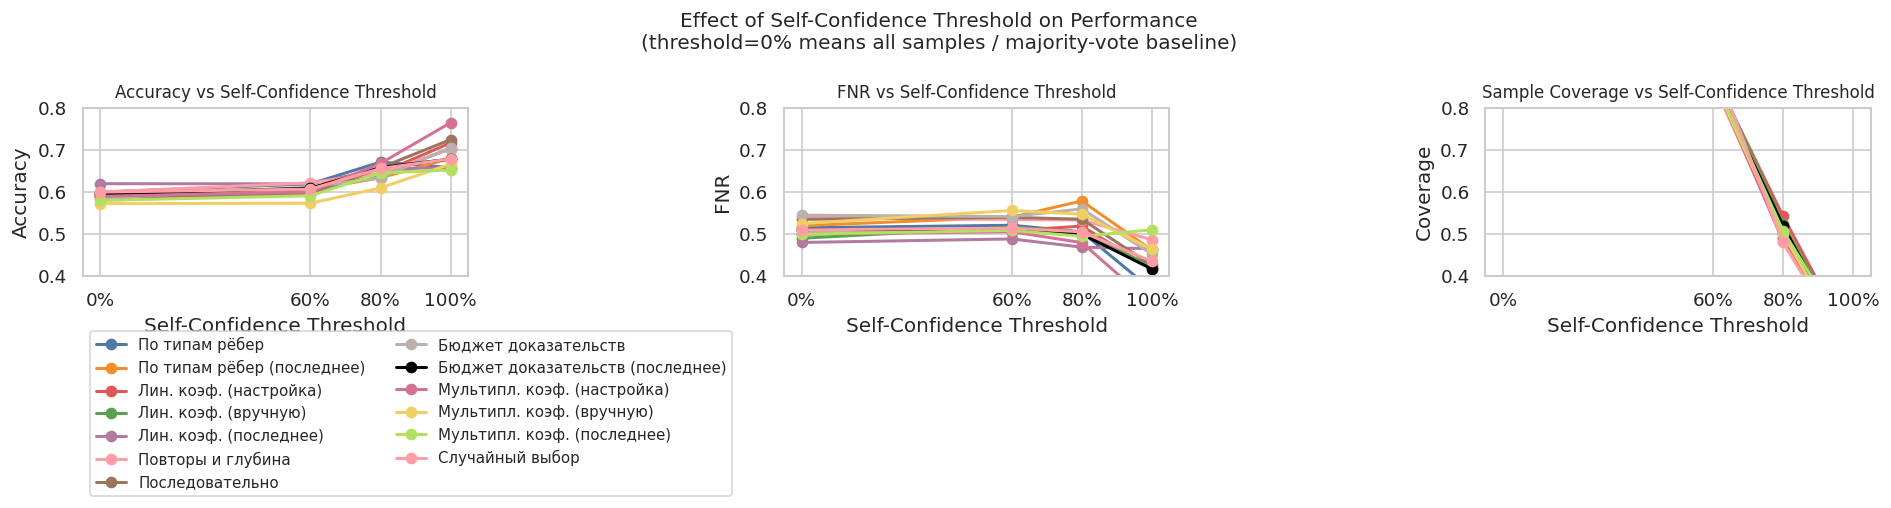

In [87]:
# Line plots: accuracy, FNR & coverage vs confidence threshold

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (col, ylabel, title) in zip(axes, [
    ('accuracy', 'Accuracy',  'Accuracy vs Self-Confidence Threshold'),
    ('FNR',      'FNR',       'FNR vs Self-Confidence Threshold'),
    ('coverage', 'Coverage',  'Sample Coverage vs Self-Confidence Threshold'),
]):
    for i, (name, _) in enumerate(data.items()):
        label = APPROACH_DISPLAY[name]
        sub   = full_conf_df[full_conf_df['approach'] == label].sort_values('threshold')
        ax.plot(sub['threshold'], sub[col], marker='o', label=label,
                color=APPROACH_COLORS[i], linewidth=1.8)
    ax.set_xlabel('Self-Confidence Threshold')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(all_thresholds)
    ax.set_xticklabels([f'{t:.0%}' for t in all_thresholds])
    ax.set_ylim(0.4, 0.8)

axes[0].legend(bbox_to_anchor=(0, -0.28), loc='upper left', ncol=2, fontsize=9)
fig.suptitle(
    'Effect of Self-Confidence Threshold on Performance\n'
    '(threshold=0% means all samples / majority-vote baseline)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

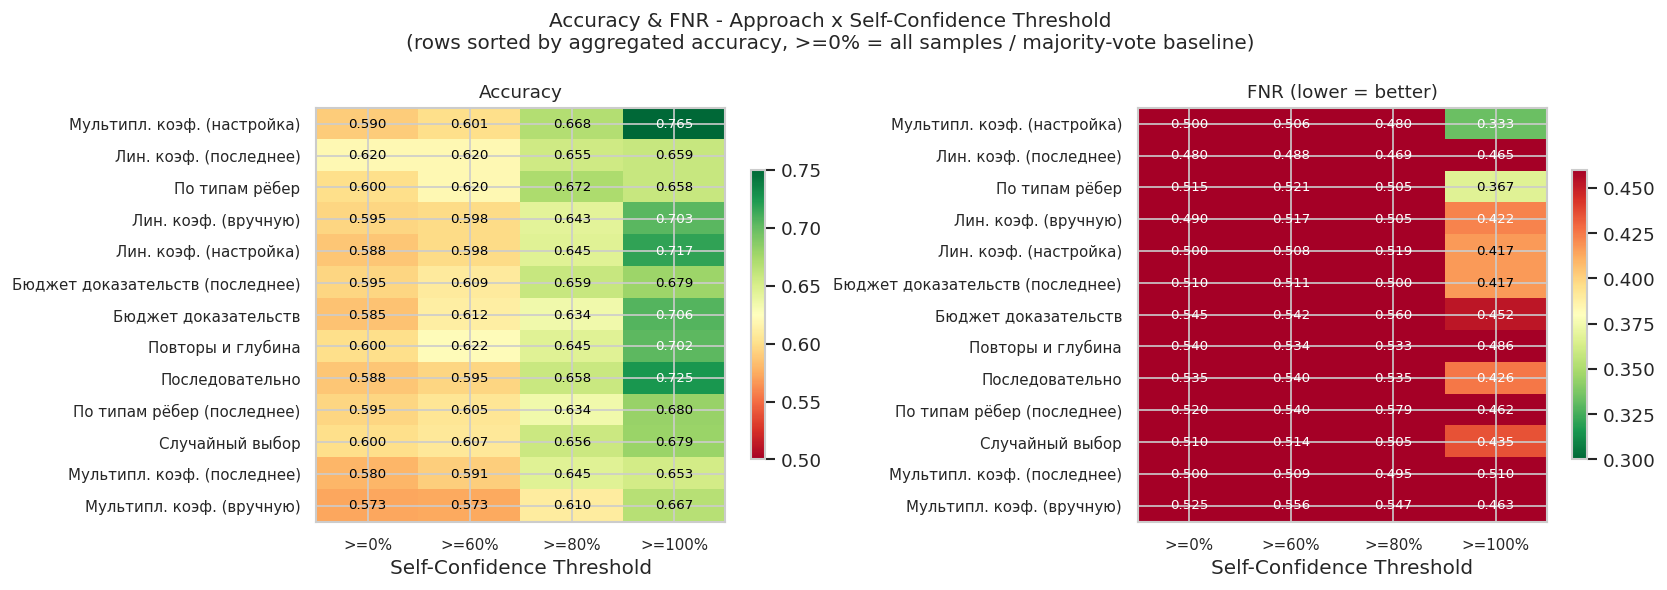

In [88]:
# Heatmaps: accuracy and FNR per (approach, threshold)

thresholds_str = [f'>={t:.0%}' for t in all_thresholds]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, cmap, vmin, vmax, title) in zip(axes, [
    ('accuracy', 'RdYlGn',   0.5, 0.75, 'Accuracy'),
    ('FNR',      'RdYlGn_r', 0.30, 0.46, 'FNR (lower = better)'),
]):
    pivot = (
        full_conf_df
        .assign(thr_label=lambda df: df['threshold'].map(lambda t: f'>={t:.0%}'))
        .pivot_table(index='approach', columns='thr_label', values=col, aggfunc='first')
        .reindex(index=approaches_by_agg_acc, columns=thresholds_str)
    )
    im = ax.imshow(pivot.values.astype(float), cmap=cmap,
                   vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(thresholds_str)))
    ax.set_xticklabels(thresholds_str, fontsize=9)
    ax.set_yticks(range(len(approaches_by_agg_acc)))
    ax.set_yticklabels(approaches_by_agg_acc, fontsize=9)
    ax.set_xlabel('Self-Confidence Threshold')
    ax.set_title(title, fontsize=11)
    for i, ap in enumerate(approaches_by_agg_acc):
        for j, tl in enumerate(thresholds_str):
            v = pivot.loc[ap, tl]
            if not np.isnan(v):
                mid_lo = vmin + 0.25 * (vmax - vmin)
                mid_hi = vmin + 0.75 * (vmax - vmin)
                tc = 'black' if mid_lo < v < mid_hi else 'white'
                ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8, color=tc)
    plt.colorbar(im, ax=ax, shrink=0.7)

fig.suptitle(
    'Accuracy & FNR - Approach x Self-Confidence Threshold\n'
    '(rows sorted by aggregated accuracy, >=0% = all samples / majority-vote baseline)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

In [89]:
# Detailed metrics table at each threshold

for thr in all_thresholds:
    sub = (
        full_conf_df[full_conf_df['threshold'] == thr]
        .set_index('approach')
        .reindex(approaches_by_agg_acc)
        [['n_samples', 'coverage', 'TP', 'TN', 'FP', 'FN',
          'accuracy', 'FNR', 'FPR', 'precision', 'recall', 'f1', 'MCC']]
    )
    print(f'\n--- Self-Confidence Threshold >= {thr:.0%} ---')
    display(
        sub.round(4)
        .style
        .background_gradient(subset=['accuracy', 'f1', 'MCC'], cmap='RdYlGn', axis=0)
        .background_gradient(subset=['FNR', 'FPR'], cmap='RdYlGn_r', axis=0)
        .background_gradient(subset=['coverage'], cmap='Blues', axis=0)
        .format('{:.4f}', subset=['coverage', 'accuracy', 'FNR', 'FPR',
                                   'precision', 'recall', 'f1', 'MCC'])
        .format('{:.0f}', subset=['n_samples', 'TP', 'TN', 'FP', 'FN'])
    )


--- Self-Confidence Threshold >= 0% ---


,n_samples,coverage,TP,TN,FP,FN,accuracy,FNR,FPR,precision,recall,f1,MCC
approach,,,,,,,,,,,,,
Мультипл. коэф. (настройка),400,1.0000,100,136,64,100,0.5900,0.5000,0.3200,0.6098,0.5000,0.5495,0.1830
Лин. коэф. (последнее),400,1.0000,104,144,56,96,0.6200,0.4800,0.2800,0.6500,0.5200,0.5778,0.2449
По типам рёбер,400,1.0000,97,143,57,103,0.6000,0.5150,0.2850,0.6299,0.4850,0.5480,0.2055
Лин. коэф. (вручную),400,1.0000,102,136,64,98,0.5950,0.4900,0.3200,0.6145,0.5100,0.5574,0.1928
Лин. коэф. (настройка),400,1.0000,100,135,65,100,0.5875,0.5000,0.3250,0.6061,0.5000,0.5479,0.1777
Бюджет доказательств (последнее),400,1.0000,98,140,60,102,0.5950,0.5100,0.3000,0.6203,0.4900,0.5475,0.1943
Бюджет доказательств,400,1.0000,91,143,57,109,0.5850,0.5450,0.2850,0.6149,0.4550,0.5230,0.1761
Повторы и глубина,400,1.0000,92,148,52,108,0.6000,0.5400,0.2600,0.6389,0.4600,0.5349,0.2083
Последовательно,400,1.0000,93,142,58,107,0.5875,0.5350,0.2900,0.6159,0.4650,0.5299,0.1805



--- Self-Confidence Threshold >= 60% ---


,n_samples,coverage,TP,TN,FP,FN,accuracy,FNR,FPR,precision,recall,f1,MCC
approach,,,,,,,,,,,,,
Мультипл. коэф. (настройка),348,0.8700,89,120,48,91,0.6006,0.5056,0.2857,0.6496,0.4944,0.5615,0.2135
Лин. коэф. (последнее),355,0.8875,88,132,51,84,0.6197,0.4884,0.2787,0.6331,0.5116,0.5659,0.2385
По типам рёбер,347,0.8675,80,135,45,87,0.6196,0.5210,0.2500,0.6400,0.4790,0.5479,0.2384
Лин. коэф. (вручную),356,0.8900,87,126,50,93,0.5983,0.5167,0.2841,0.6350,0.4833,0.5489,0.2047
Лин. коэф. (настройка),353,0.8825,87,124,52,90,0.5977,0.5085,0.2955,0.6259,0.4915,0.5506,0.2007
Бюджет доказательств (последнее),348,0.8700,85,127,47,89,0.6092,0.5115,0.2701,0.6439,0.4885,0.5556,0.2250
Бюджет доказательств,348,0.8700,77,136,44,91,0.6121,0.5417,0.2444,0.6364,0.4583,0.5329,0.2244
Повторы и глубина,344,0.8600,81,133,37,93,0.6221,0.5345,0.2176,0.6864,0.4655,0.5548,0.2611
Последовательно,348,0.8700,81,126,46,95,0.5948,0.5398,0.2674,0.6378,0.4602,0.5347,0.2002



--- Self-Confidence Threshold >= 80% ---


,n_samples,coverage,TP,TN,FP,FN,accuracy,FNR,FPR,precision,recall,f1,MCC
approach,,,,,,,,,,,,,
Мультипл. коэф. (настройка),193,0.4825,51,78,17,47,0.6684,0.4796,0.1789,0.7500,0.5204,0.6145,0.3574
Лин. коэф. (последнее),200,0.5000,51,80,24,45,0.6550,0.4688,0.2308,0.6800,0.5312,0.5965,0.3101
По типам рёбер,204,0.5100,48,89,18,49,0.6716,0.5052,0.1682,0.7273,0.4948,0.5890,0.3487
Лин. коэф. (вручную),210,0.5250,50,85,24,51,0.6429,0.5050,0.2202,0.6757,0.4950,0.5714,0.2875
Лин. коэф. (настройка),217,0.5425,51,89,22,55,0.6452,0.5189,0.1982,0.6986,0.4811,0.5698,0.2993
Бюджет доказательств (последнее),208,0.5200,51,86,20,51,0.6587,0.5000,0.1887,0.7183,0.5000,0.5896,0.3282
Бюджет доказательств,205,0.5125,44,86,19,56,0.6341,0.5600,0.1810,0.6984,0.4400,0.5399,0.2806
Повторы и глубина,197,0.4925,42,85,22,48,0.6447,0.5333,0.2056,0.6562,0.4667,0.5455,0.2777
Последовательно,196,0.4900,46,83,14,53,0.6582,0.5354,0.1443,0.7667,0.4646,0.5786,0.3475



--- Self-Confidence Threshold >= 100% ---


,n_samples,coverage,TP,TN,FP,FN,accuracy,FNR,FPR,precision,recall,f1,MCC
approach,,,,,,,,,,,,,
Мультипл. коэф. (настройка),81,0.2025,26,36,6,13,0.7654,0.3333,0.1429,0.8125,0.6667,0.7324,0.5354
Лин. коэф. (последнее),82,0.2050,23,31,8,20,0.6585,0.4651,0.2051,0.7419,0.5349,0.6216,0.3396
По типам рёбер,79,0.1975,31,21,9,18,0.6582,0.3673,0.3000,0.7750,0.6327,0.6966,0.3229
Лин. коэф. (вручную),91,0.2275,26,38,8,19,0.7033,0.4222,0.1739,0.7647,0.5778,0.6582,0.4174
Лин. коэф. (настройка),92,0.2300,28,38,6,20,0.7174,0.4167,0.1364,0.8235,0.5833,0.6829,0.4626
Бюджет доказательств (последнее),84,0.2100,28,29,7,20,0.6786,0.4167,0.1944,0.8000,0.5833,0.6747,0.3904
Бюджет доказательств,85,0.2125,23,37,6,19,0.7059,0.4524,0.1395,0.7931,0.5476,0.6479,0.4303
Повторы и глубина,84,0.2100,19,40,7,18,0.7024,0.4865,0.1489,0.7308,0.5135,0.6032,0.3915
Последовательно,80,0.2000,27,31,2,20,0.7250,0.4255,0.0606,0.9310,0.5745,0.7105,0.5262


## Self-Confidence Calibration

Does higher self-confidence correlate with being correct?
A well-calibrated confidence signal should show higher accuracy at higher confidence levels.

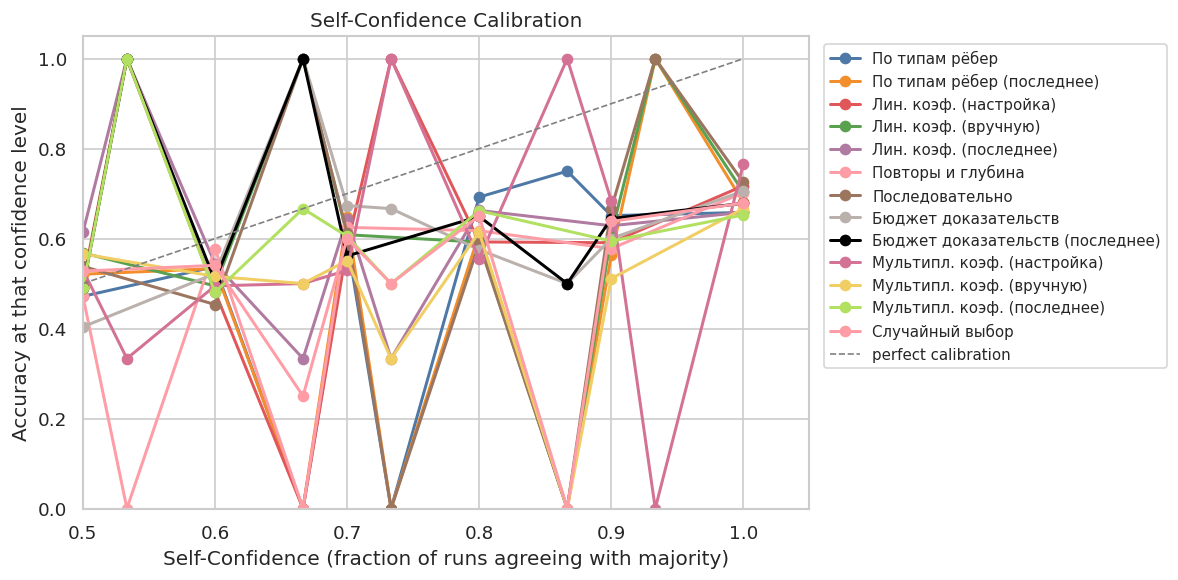

confidence,0.500000,0.533333,0.600000,0.666667,0.700000,0.733333,0.800000,0.866667,0.900000,0.933333,1.000000
approach,,,,,,,,,,,
Мультипл. коэф. (настройка),0.531,0.333,0.495,0.500,0.529,1.000,0.556,1.000,0.684,0.000,0.765
Лин. коэф. (последнее),0.614,1.000,0.544,0.333,0.644,0.333,0.663,nan,0.629,nan,0.659
По типам рёбер,0.472,nan,0.538,0.000,0.596,0.000,0.692,0.750,0.651,nan,0.658
Лин. коэф. (вручную),0.568,nan,0.495,1.000,0.609,nan,0.592,0.000,0.610,1.000,0.703
Лин. коэф. (настройка),0.500,1.000,0.482,0.000,0.583,1.000,0.593,nan,0.591,nan,0.717
Бюджет доказательств (последнее),0.490,1.000,0.506,1.000,0.561,nan,0.649,0.500,0.644,nan,0.679
Бюджет доказательств,0.404,nan,0.522,1.000,0.673,0.667,0.575,0.500,0.600,nan,0.706
Повторы и глубина,0.473,0.000,0.578,0.000,0.625,nan,0.618,nan,0.578,nan,0.702
Последовательно,0.538,nan,0.453,1.000,0.613,0.000,0.590,0.000,0.667,1.000,0.725


In [90]:
# Accuracy at each confidence level (calibration)

cal_rows = []
for name, v in data.items():
    sdf = v['sample_df'].copy()
    sdf['correct'] = (sdf['majority_pred'] == sdf['true_label']).astype(int)
    for conf, grp in sdf.groupby('confidence'):
        cal_rows.append({
            'approach':  APPROACH_DISPLAY[name],
            'confidence': conf,
            'accuracy':  grp['correct'].mean(),
            'n':         len(grp),
        })
cal_df = pd.DataFrame(cal_rows)

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, _) in enumerate(data.items()):
    label = APPROACH_DISPLAY[name]
    sub = cal_df[cal_df['approach'] == label].sort_values('confidence')
    ax.plot(sub['confidence'], sub['accuracy'], marker='o', label=label,
            color=APPROACH_COLORS[i], linewidth=1.8)

ax.plot([0.5, 1.0], [0.5, 1.0], color='gray', linestyle='--',
        linewidth=1, label='perfect calibration')
ax.set_xlabel('Self-Confidence (fraction of runs agreeing with majority)')
ax.set_ylabel('Accuracy at that confidence level')
ax.set_title('Self-Confidence Calibration')
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.0, 1.05)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

display(
    cal_df.pivot_table(index='approach', columns='confidence',
                       values='accuracy', aggfunc='first')
    .reindex(index=approaches_by_agg_acc)
    .round(3)
    .style
    .background_gradient(cmap='RdYlGn', vmin=0.4, vmax=0.9, axis=None)
    .format('{:.3f}')
    .set_caption('Accuracy at Each Confidence Level (NaN = no samples at that confidence)')
)

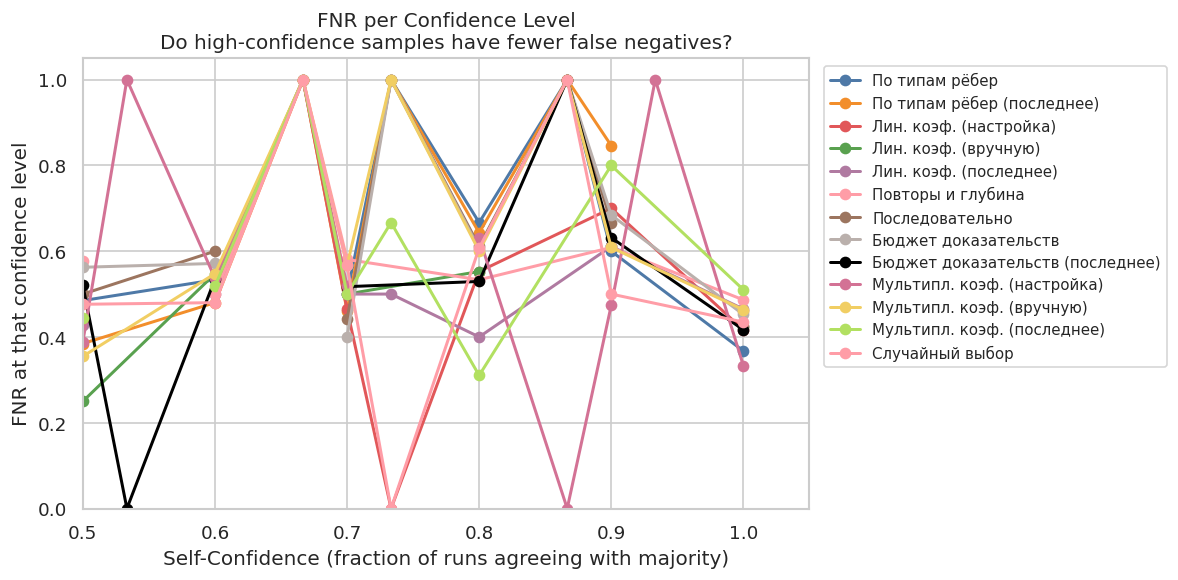

In [91]:
# FNR at each confidence level

fnr_rows = []
for name, v in data.items():
    sdf = v['sample_df']
    for conf, grp in sdf.groupby('confidence'):
        pos = grp[grp['true_label'] == 1]
        fn  = int((pos['majority_pred'] == 0).sum())
        fnr = fn / len(pos) if len(pos) else float('nan')
        fnr_rows.append({'approach': APPROACH_DISPLAY[name], 'confidence': conf, 'FNR': fnr})
fnr_cal_df = pd.DataFrame(fnr_rows)

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, _) in enumerate(data.items()):
    label = APPROACH_DISPLAY[name]
    sub = fnr_cal_df[fnr_cal_df['approach'] == label].sort_values('confidence')
    ax.plot(sub['confidence'], sub['FNR'], marker='o', label=label,
            color=APPROACH_COLORS[i], linewidth=1.8)
ax.set_xlabel('Self-Confidence (fraction of runs agreeing with majority)')
ax.set_ylabel('FNR at that confidence level')
ax.set_title('FNR per Confidence Level\nDo high-confidence samples have fewer false negatives?')
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.0, 1.05)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

## Summary

In [92]:
# Best approach at each threshold

print('Best approach by ACCURACY at each self-confidence threshold:')
for thr in all_thresholds:
    sub  = full_conf_df[full_conf_df['threshold'] == thr]
    best = sub.loc[sub['accuracy'].idxmax()]
    print(
        f"  >={thr:.0%}  ->  {best['approach']:>14}  "
        f"acc={best['accuracy']:.4f}  "
        f"FNR={best['FNR']:.4f}  "
        f"coverage={best['coverage']:.1%}"
    )

print()
print('Best approach by FNR (lowest) at each self-confidence threshold:')
for thr in all_thresholds:
    sub  = full_conf_df[full_conf_df['threshold'] == thr]
    best = sub.loc[sub['FNR'].idxmin()]
    print(
        f"  >={thr:.0%}  ->  {best['approach']:>14}  "
        f"FNR={best['FNR']:.4f}  "
        f"acc={best['accuracy']:.4f}  "
        f"coverage={best['coverage']:.1%}"
    )

Best approach by ACCURACY at each self-confidence threshold:
  >=0%  ->  Лин. коэф. (последнее)  acc=0.6200  FNR=0.4800  coverage=100.0%
  >=60%  ->  Повторы и глубина  acc=0.6221  FNR=0.5345  coverage=86.0%
  >=80%  ->  По типам рёбер  acc=0.6716  FNR=0.5052  coverage=51.0%
  >=100%  ->  Мультипл. коэф. (настройка)  acc=0.7654  FNR=0.3333  coverage=20.2%

Best approach by FNR (lowest) at each self-confidence threshold:
  >=0%  ->  Лин. коэф. (последнее)  FNR=0.4800  acc=0.6200  coverage=100.0%
  >=60%  ->  Лин. коэф. (последнее)  FNR=0.4884  acc=0.6197  coverage=88.8%
  >=80%  ->  Лин. коэф. (последнее)  FNR=0.4688  acc=0.6550  coverage=50.0%
  >=100%  ->  Мультипл. коэф. (настройка)  FNR=0.3333  acc=0.7654  coverage=20.2%


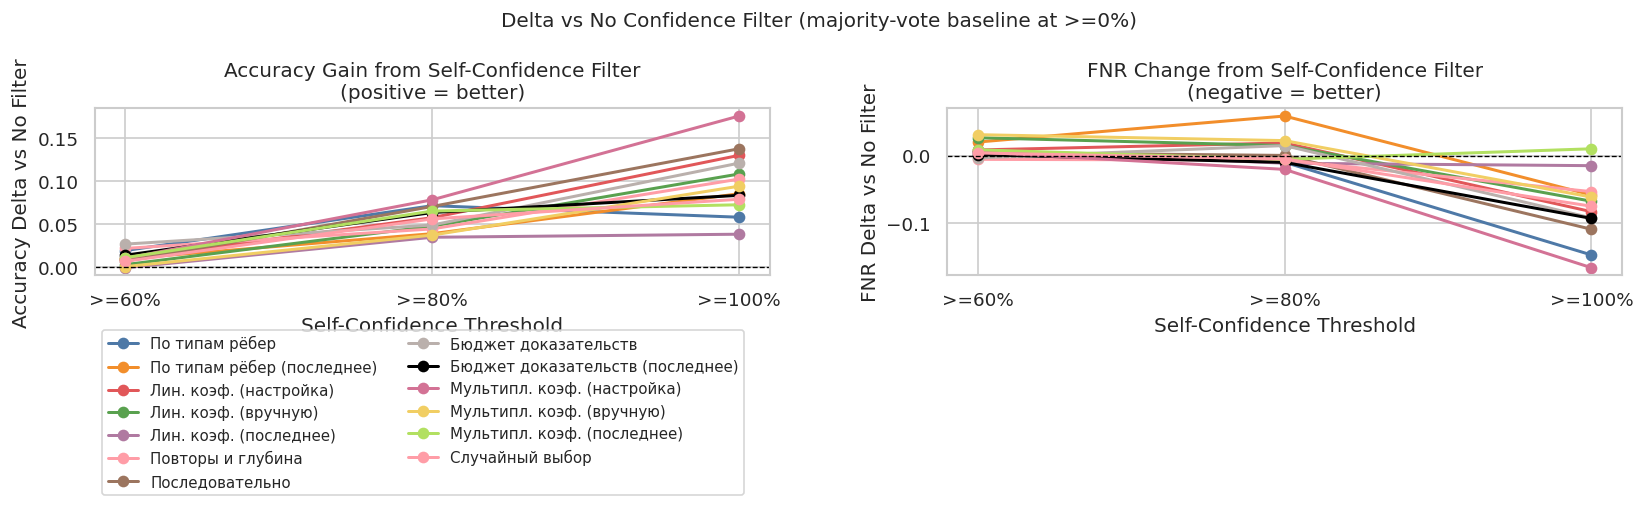

In [93]:
# Delta: metric(threshold) - metric(no filter) per approach

base = (
    full_conf_df[full_conf_df['threshold'] == 0.0]
    [['approach', 'accuracy', 'FNR']]
    .rename(columns={'accuracy': 'acc_base', 'FNR': 'fnr_base'})
)
delta_df = full_conf_df[full_conf_df['threshold'] > 0].merge(base, on='approach')
delta_df['delta_acc'] = delta_df['accuracy'] - delta_df['acc_base']
delta_df['delta_fnr'] = delta_df['FNR']      - delta_df['fnr_base']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
thr_labels = [f'>={t:.0%}' for t in CONF_THRESHOLDS]

for ax, (col, ylabel, title, note) in zip(axes, [
    ('delta_acc', 'Accuracy Delta vs No Filter',
     'Accuracy Gain from Self-Confidence Filter', '(positive = better)'),
    ('delta_fnr', 'FNR Delta vs No Filter',
     'FNR Change from Self-Confidence Filter',    '(negative = better)'),
]):
    for i, (name, _) in enumerate(data.items()):
        label = APPROACH_DISPLAY[name]
        sub   = (
            delta_df[delta_df['approach'] == label]
            .sort_values('threshold')
            .assign(thr_label=lambda d: d['threshold'].map(lambda t: f'>={t:.0%}'))
        )
        ax.plot(sub['thr_label'], sub[col], marker='o', label=label,
                color=APPROACH_COLORS[i], linewidth=1.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Self-Confidence Threshold')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\n{note}')

axes[0].legend(bbox_to_anchor=(0, -0.28), loc='upper left', ncol=2, fontsize=9)
fig.suptitle(
    'Delta vs No Confidence Filter (majority-vote baseline at >=0%)',
    fontsize=12,
)
fig.tight_layout()
plt.show()